## Esercizio 1

Sia $X$ una variabile aleatoria distribuita secondo un modello di Poisson di parametro $\lambda$.

1. Considerate le seguenti affermazioni e, per ognuna, dite se è vera o falsa, motivando le vostre risposte:

   * $\lambda$ può assumere un valore maggiore di 1;
   * $\lambda$ deve sempre assumere valori interi;
   * $\lambda$ non può mai essere negativo;
   * $X$ può sempre assumere specificazioni maggiori di $\lambda$.

2. Fissato $n \in \mathbb{N}$ siano $X_1, ..., X_n$ variabili aleatorie indipendenti e identicamente distribuite come $X$. Indichiamo con $S$ la somma $\sum_{i=1}^{n} X_i$. Che distribuzione segue $S$? Perché?

3. Dato un generico numero naturale $z$, esprimete $\mathbb{P}(S=z)$ in funzione di $\lambda$, $n$ e $z$.

4. Sia $\bar{S} = \frac{1}{n} \sum_{i=1}^{n} X_i$. Indicate quali sono i valori che può assumere $\bar{S}$ ed esprimete $\mathbb{P}(\bar{S} = x)$ in funzione di $\lambda$, $n$ e $x$.

5. Fissiamo, solo in questo punto, $\lambda = 0.9$ e $n = 15$. Utilizzando il computer visualizzate il grafico della funzione di massa di probabilità di $\bar{S}$, motivando la scelta fatta. Se non avete risposto alla domanda 4, potete visualizzare l'analogo grafico per $S$.

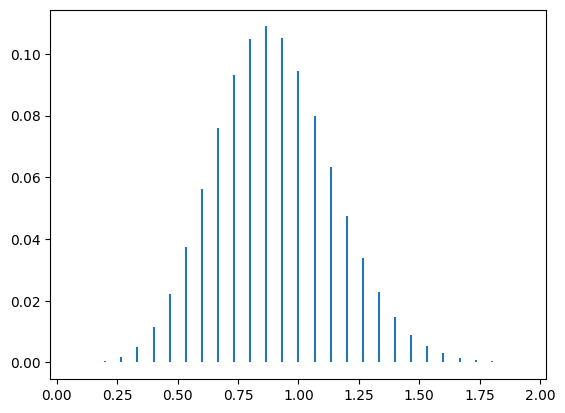

In [ ]:
# 1.
# lambda rappresenta la media di volte che un evento può accadere in un determinato lasso di tempo
# quindi: 
# - può assumere valori maggiori di 1 
# - può essere frazionario dato che è una media
# - non può essere negativo dato che non puoi avere tempo negativo
# - X può assumere valori maggiori dato che è una media

# 2.
# S segue una distribuzione di Poisson di parametro n*lambda, per la riproducibilità di Poisson (anche le normali la hanno)

# 3. P(S=z) -> e**(-n*lambda) * (n*lambda)**z  / z!

# 4. S' non è più una Poisson, è uguale a S/n
# P(S/n=x) -> P(S=nx) -> e**(-n*lambda) * (n*lambda)**(n*x)  / (n*x)!

#5. 

import matplotlib.pyplot as plt
import scipy.stats as st
import numpy as np
import pandas as pd
import math

l = 0.9
n = 15

x_range = np.arange(1, 30)
y_range = st.poisson(l*n).pmf(x_range)

plt.vlines(x_range/n,0,y_range)
plt.show()

# uhm ho scelto vlines per visualizzare le probabilità ecco...

## Esercizio 2

Per $n \in \mathbb{N}$ fissato, sia $X_1, ..., X_n$ un campione aleatorio estratto da una popolazione modellata tramite la variabile aleatoria $X$ descritta nell'Esercizio 1.

1. La variabile aleatoria $T = \frac{1}{n} \sum_{i=1}^{n} iX_i$ è uno stimatore non deviato per $\lambda$? Perché?

2. La variabile aleatoria $\bar{S}$ introdotta nell'esercizio precedente è uno stimatore non deviato per $\lambda$? Perché?

3. $\bar{S}$ è uno stimatore non deviato per $\sigma^2 = Var(X)$? Calcolate il suo bias e il suo MSE rispetto a $\sigma^2$. Indicate se esso gode anche della proprietà di consistenza in media quadratica.

4. Applicando il teorema centrale del limite, calcolate la probabilità dell'evento $E$ che si verifica quando l'errore (in valore assoluto) che si compie usando $\bar{S}$ per stimare $\lambda$ sia minore o uguale a $\epsilon$, esprimendola in funzione di $n$, $\epsilon$ e $\lambda$.

5. Fissando, solo in questo punto, $\lambda = 0.9$ ed $\epsilon = 0.05$, scrivete ed eseguite del codice che mostra come la probabilità calcolata al punto precedente tenda a 1 all'aumentare della dimensione del campione. Commentate il risultato ottenuto, spiegando il comportamento dell'andamento per i valori estremi considerati per $n$.

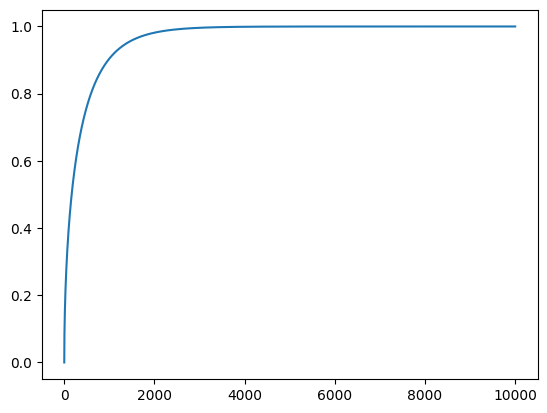

In [ ]:

# 1. 
# E(T) deve essere uguale a lambda, vediamo un po' 
# E(T) = 1/n sum(i to n) i*E(Xi) cioè lambda = lambda/n * sum(i to n) i = lambda/n * n*(n+1)/2 = 
# = lambda*(n+1)/2 che è DIVERSO da lambda quindi T è distorto già già

# 2.
# S' non è distorto per lambda dato che E(X)=lambda 
# e la media campionaria (S') è sempre uno stimatore non distorto per E(X)
# non mi credi? fatti tu i conti

# 3.
# S' è uno stimatore non deviato per Var(x)? sì perché E(X)=lambda=Var(X) (quando si tratta di pesce (scusate autocorrettore))
# bias = E(S') - tao(theta) = lambda - lambda = 0
# MSE = Var(S') + bias**2 = Var(S)/n + 0 = lambda/n
# Consistente? lim n->infinito MSE = lambda/infinito = 0. Sì è consistente

# 4. 
# P(|S' - lambda| <= 0.5) = 2*phi(0.5*sqrt(n)/sqrt(lambda)) - 1  


# 5.

l = 0.9
epsilon = 0.05

n_range = np.arange(0,10000)
y_range = [2*st.norm.cdf(epsilon*np.sqrt(n)/np.sqrt(l))-1 for n in n_range]


plt.plot(n_range, y_range)
plt.show()

## Esercizio 3

1. Caricate il dataset e memorizzatelo in una variabile `accessi`. Scrivete ed eseguite del codice il cui output indichi quanti valori mancanti vi siano per ogni possibile valore dell'attributo `allarme`. Determinate poi quali sono gli attributi del dataset per i quali è presente almeno un valore mancante.

2. Indicate il tipo dell'attributo `allarme` e descrivete questo attributo utilizzando la rappresentazione grafica che ritenete più adeguata, motivando la scelta fatta.

3. Valutate l'ipotesi che il carico di sistema influisca sul sistema che emette gli allarmi, indicando quali strumenti avete utilizzato e commentando i risultati ottenuti.

4. Fissato un generico numero $f$ compreso tra 0 e 100, vogliamo determinare il numero $n$ che rende vera l'affermazione "nell'f% dei casi sono arrivate al massimo $n$ richieste". Visualizzate graficamente la distribuzione dell'attributo `richieste` utilizzando il tipo di grafico più adeguato per determinare $n$.

5. Usando il grafico generato al punto precedente, determinate il valore di $n$ che corrisponde a $f = 95$.

6. Visualizzate la tabella delle frequenze relative congiunte degli attributi `richieste` e `allarme`.

7. Indicando con $A$ l'evento che si verifica quando è stato emesso un allarme e con $R$ l'evento che si verifica quando nel periodo di riferimento è stato effettuato almeno un accesso al server, usate la tabella ottenuta al punto precedente per stimare le seguenti probabilità: i. $\mathbb{P}(R)$, ii. $\mathbb{P}(A \cap R)$, iii. $\mathbb{P}(R \vert A)$, iv. $\mathbb{P}(A \vert R)$.

8. Le probabilità che avete stimato al punto precedente devono sommare a uno? Perché?

9. Validate o confutate l'ipotesi che i valori dell'attributo `richieste` siano assimilabili a un campione estratto da una distribuzione normale.

10. Calcolate la media campionaria e la varianza campionaria dell'attributo `richieste`, e utilizzate i risultati per rispondere alla domanda precedente, considerando ora una distribuzione di Poisson.

In [4]:
accessi = pd.read_csv('accessi.csv')

accessi.head()

,timestamp,richieste,allarme,carico
0,2025-01-01 00:00:00,12.0,1.0,2.130720
1,2025-01-01 00:01:00,6.0,0.0,1.808862
2,2025-01-01 00:02:00,11.0,0.0,2.654687
3,2025-01-01 00:03:00,14.0,0.0,2.737970
4,2025-01-01 00:04:00,7.0,0.0,1.619333


In [6]:
# 1. valori mancanti

for c in accessi:
    print(f"colonna {c} ha {sum(accessi[c].isna())} valori mancanti")

colonna timestamp ha 0 valori mancanti
colonna richieste ha 13 valori mancanti
colonna allarme ha 35 valori mancanti
colonna carico ha 7 valori mancanti


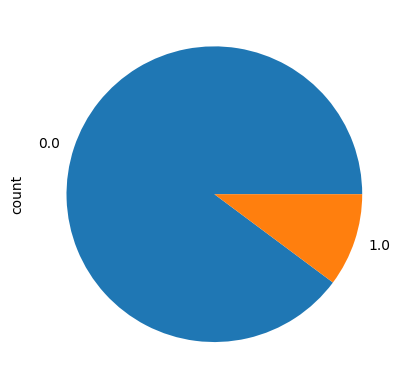

In [ ]:
# 2. rappresenta allarme

accessi.allarme.value_counts().plot.pie()
plt.show()

# allarme è una bernulliana
# può essere rappresentata da un pie chart per vedere la relazione fra true e false

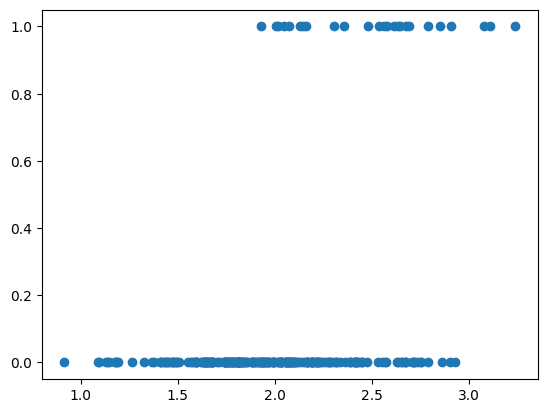

np.float64(0.3870909789623797)

In [ ]:
# 3. valuta se il carico ha effetto sugli allarmi

plt.scatter(accessi.carico, accessi.allarme)
plt.show()

accessi.carico.corr(accessi.allarme)

# sia dallo scatter plot sia dal coefficiente di pearson si può notare una leggera 
# corrispondenza diretta fra il carico e l'accadimentod di un allarme

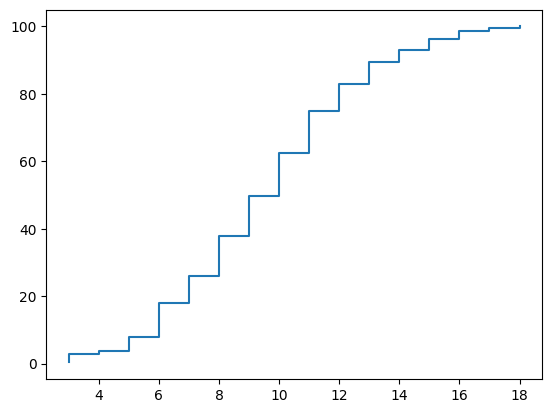

In [66]:
# 4 trova la % massima dove i casi non superano n richieste

richieste = accessi.richieste.dropna().sort_values()
cdf = np.arange(1, len(richieste) + 1) / len(richieste) * 100  # in percentuale
plt.step(richieste, cdf)
plt.show()

In [47]:
# 5. n con f = 95

richieste.quantile(0.95)

np.float64(15.0)

In [50]:
# 6. visualizza tabella delle frequenze relative congiunte di richieste e allarme

pd.crosstab(accessi.richieste,accessi.allarme, normalize=True, margins=True)

allarme,0.0,1.0,All
richieste,,,
3.0,0.019608,0.000000,0.019608
4.0,0.007843,0.000000,0.007843
5.0,0.043137,0.000000,0.043137
6.0,0.098039,0.000000,0.098039
7.0,0.086275,0.000000,0.086275
8.0,0.113725,0.000000,0.113725
9.0,0.121569,0.000000,0.121569
10.0,0.133333,0.000000,0.133333
11.0,0.109804,0.007843,0.117647


In [ ]:
# 7. 
# P(R) = 1 il dataset non ha 0 richieste
# P(A int. R) = 0.094118
# P(R dato A) = 0.094118/0.094118 = 1 se c'è un allarme allora per forza ci sono richieste
# P(A dato R) = 0.094118/1 = 0.094118 hey colpa di chatgpt non mia

# 8. Le probabilità devono sommare a 1?
# ovvio che no dai non c'entrano niente
# la probabilità che ci siano richieste P(R) + 
# la probabilità che ci siano richieste e che l'allarme sia suonato P(A int. R)
# già potrebbe sforare l'uno quindi manco serve guardare gli altri

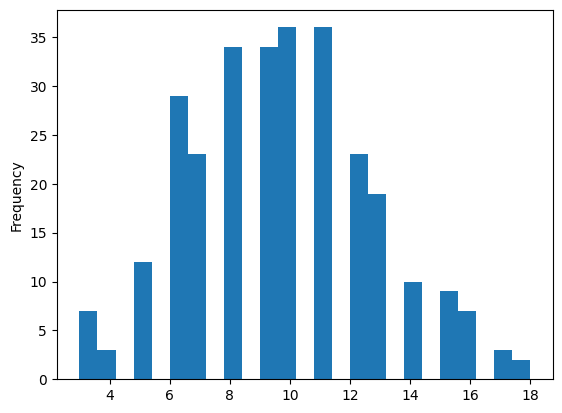

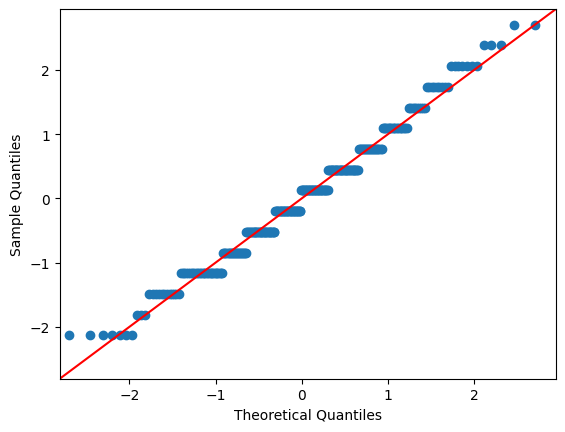

In [ ]:
# 9. Richieste segue una distribuzione normale?

import statsmodels.api as sm

accessi.richieste.plot.hist(bins=25)
plt.show()

sm.qqplot(accessi.richieste.dropna(), st.norm, line='45', fit=True)
plt.show()

# guarda io direi di sì
# guardando l'istogramma che ho disegnato direi anche che mancano un po' di dati però ci sta
# e ciò è sbagliato dato che es 4 parla di esperti e poisson, colpa di chatgpt o degli esperti

In [ ]:
# 10. Calcola valore atteso e varianza di richieste e ipotizza segua Poisson

print(f"E(X)={accessi.richieste.mean()} e Var(X)={accessi.richieste.var()}")

# sono molto vicini, quindi potrebbe anche trattarsi di una Poisson 
# dato che lì E(X)=Var(X)=lambda, in questo caso lambda sarebbe ~ 9.6

E(X)=9.613240418118467 e Var(X)=9.650593309129894


## Esercizio 4

Gli esperti ritengono che la distribuzione del numero di richieste segua una distribuzione di Poisson (di parametro ignoto) se si considerano solamente i casi nei quali è stato emesso un allarme.

1. Memorizzate in una variabile `allarme_si` i valori dell'attributo richieste che si riferiscono a tutti e soli i casi nei quali è stato emesso un allarme.

2. Ripetete l'analisi fatta all'ultimo punto dell'esercizio 3, considerando solo i casi contenuti in `allarme_si`.

3. Nel resto di questo esercizio, supporremo che i valori contenuti in `allarme_si` siano assimilabili a un campione estratto da una popolazione $X$ che segue una distribuzione di Poisson di parametro $\lambda$. Stimate questo parametro.

4. Utilizzando la stima ottenuta al punto precedente, confermate ulteriormente l'ipotesi che i valori contenuti in `allarme_si` siano descritti da una distribuzione appartenente al modello di Poisson.

5. Con quale probabilità potete garantire che la stima fatta al punto 3 disti in valore assoluto dal valore sconosciuto più di 0.05?

6. Considerate le seguenti affermazioni, e per ognuno di essi scrivete l'evento corrispondente nei termini della variabile aleatoria $X$ che descrive la popolazione del numero di richieste quando viene generato un allarme, e successivamente calcolate la relativa probabilità, sostituendo al parametro ignoto la stima che avete ottenuto per esso:

   - Il numero di richieste è superiore a 3;
   - Sono arrivate esattamente 3 richieste;
   - Il numero di richieste è compreso tra 2 e 3, estremi inclusi.

7. L'azienda sta sviluppando un sistema real time, da eseguire ogni volta che arriva una richiesta, per migliorare l'emissione degli allarmi. Il tempo necessario per l'esecuzione di questo sistema è di mezzo secondo. Qual è la probabilità che questo sistema non sia in grado di gestire una nuova richiesta? (Suggerimento: affinché ciò accada, il tempo tra due richieste successive deve eccedere mezzo secondo).

In [ ]:
# 1. prendi i dati con allarme positivo

allarme_si = accessi[accessi.allarme == 1]

allarme_si.head()

,timestamp,richieste,allarme,carico
0,2025-01-01 00:00:00,12.0,1.0,2.130720
22,2025-01-01 00:22:00,13.0,1.0,2.673826
33,2025-01-01 00:33:00,15.0,1.0,2.161284
43,2025-01-01 00:43:00,15.0,1.0,2.847799
50,2025-01-01 00:50:00,18.0,1.0,3.077208


E(X)=14.083333333333334 e Var(X)=4.4275362318840585


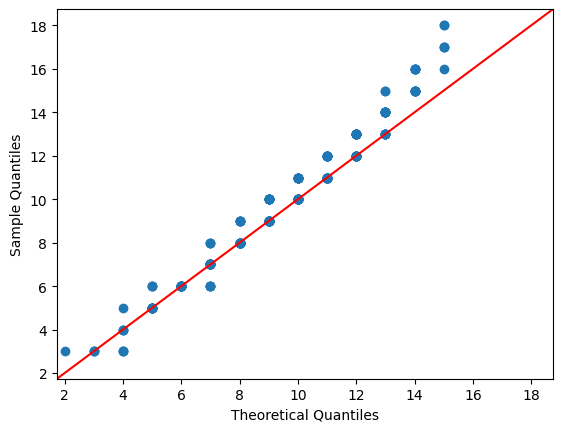

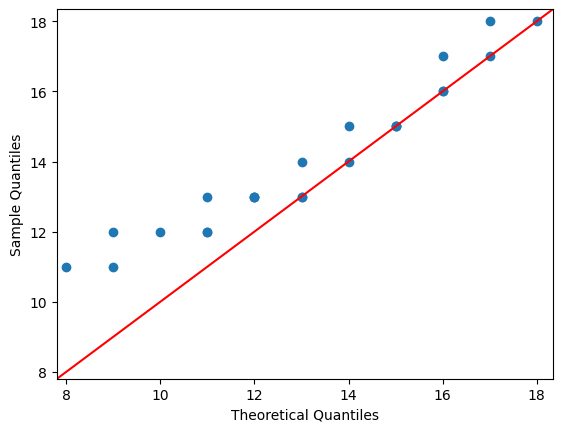

27

In [ ]:
# 2. rifai 3.10 ma solo sui casi con allarme attivato

print(f"E(X)={allarme_si.richieste.mean()} e Var(X)={allarme_si.richieste.var()}")

# beh ora non è poisson quello è sicuro

# 3. per l'esercizio invece è giusto, quindi diciamo che come per lambda è la media campionaria quindi 14
l = 14

# 4. prova l'ipotesi

# questo è con allarme sia 0 che 1, e direi che segue, un po' sporco ma si vede 
sm.qqplot(accessi.richieste, st.poisson(9.6), line='45')
plt.show()

# l'inizio non lo segue ma si stabilizza, direi che servirebbero più dati per poter dare una risposta sicura
sm.qqplot(allarme_si.richieste, st.poisson(14), line='45')
plt.show()

len(allarme_si) # soprattutto contando di star lavorando solo su 27 dati (come si poteva comodamende notare dal PIE CHART fatto all'inizio)

In [95]:
# 5.
# P(|E(X)-lambda|<=0.05) = la solita formula 2*phi(epsilon * sqrt n / sqrt dev. std) - 1
2*st.norm.cdf(0.05*np.sqrt(len(allarme_si))/math.sqrt(allarme_si.richieste.std())) - 1



np.float64(0.1421459243886105)

In [103]:
# 6. 
# P(X>3) sarebbe uguale a 1-P(X<=3)
print(f"P(X>3) = {1-st.poisson(l).cdf(3)}")
# P(X=3) è la pmf 
print(f"P(X=3) = {st.poisson(l).pmf(3)}")
# P(X=2 o 3) può essere visto come P(X=2)+P(X=3)
print(f"P(X=3) o P(X=2) = {st.poisson(l).pmf(3)+st.poisson(l).pmf(2)}")


P(X>3) = 0.9861741266477031
P(X=3) = 0.009987008567995356
P(X=3) o P(X=2) = 0.013107948745493904


In [ ]:
# 7. qual'è la probabilità che una richiesta sia meno di 0.5 secondi dopo un altra richiesta?
# non è chiaro cosa si intenda per tempo, quindi ignorerò timestamp e farò finta che richieste mostri quante richieste al minuto
# per trovare la probabilità che una richiesta venga mandata entro 0.5 secondi da quella prima
# il mio amico C.G. mi ha consigliato questa formula

media_ric_sec = accessi.richieste.mean() / 60
1 - np.exp(media_ric_sec*0.5)

# funziona? no. ma sembra giusta? no. ma sarebbe accettabile all'esame? no. ma ha lontanamente senso? no. ma ha dei fini alternativi? no. ma ha senso graficamente? no

np.float64(-0.08340660071693784)